In [ ]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine


In [ ]:
load_dotenv("../.env")

conn = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

print("Connection created")

Connection created


In [ ]:
transaction = ''' 
                SELECT *
                FROM transactions
                WHERE deal_date >< 2025'''
df_transaction = pd.read_sql(transaction,conn)
df_transaction.head()

,transaction_id,listing_id,property_id,agent_id,customer_id,city,deal_date,deal_price,commission_amount,payment_mode,deal_status
0,T00000001,L0004979,P004474,A00179,C000275,Dhaka,2024-10-20,20951990.0,530085.0,Cash,Completed
1,T00000002,L0001009,P002023,A00059,C004923,Dhaka,2023-09-07,10704517.0,294374.0,Mortgage,Completed
2,T00000003,L0008313,P004075,A00285,C005386,Chattogram,2024-05-30,11306054.0,315439.0,Mortgage,Completed
3,T00000004,L0006698,P004469,A00070,C005323,Chattogram,2023-03-10,7998580.0,205564.0,Mortgage,Completed
4,T00000005,L0002447,P000751,A00291,C001569,Rangpur,2023-07-23,5351976.0,131659.0,Mortgage,Completed


In [ ]:
tahun = pd.to_datetime(df_transaction['date_deal']).dt.year
tahun.unique()

Checking Distribution and outlier data

<Axes: xlabel='deal_price', ylabel='Count'>

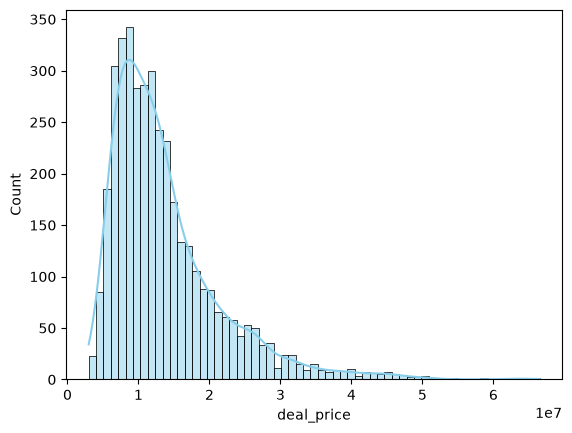

In [5]:
sns.histplot(data= df_transaction['deal_price'], kde = True, color = 'skyblue')

<Axes: ylabel='deal_price'>

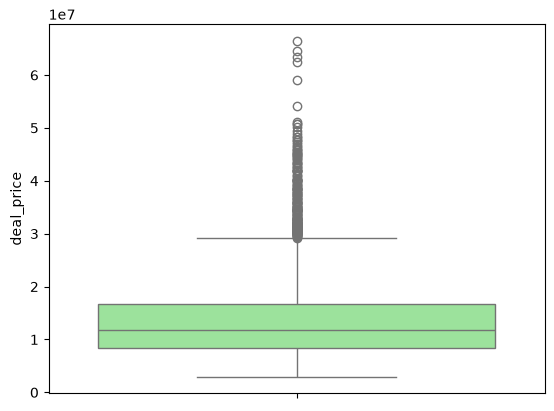

In [6]:
sns.boxplot(data = df_transaction['deal_price'],color = 'lightgreen')

In [7]:
df_transaction.describe()

,deal_price,commission_amount
count,3.922000e+03,3.922000e+03
mean,1.376959e+07,3.410162e+05
std,7.823635e+06,2.066770e+05
min,2.992547e+06,5.973000e+04
25%,8.345106e+06,2.017750e+05
50%,1.175462e+07,2.833465e+05
75%,1.665520e+07,4.154322e+05
max,6.651116e+07,1.982681e+06


<Axes: xlabel='commission_amount', ylabel='Count'>

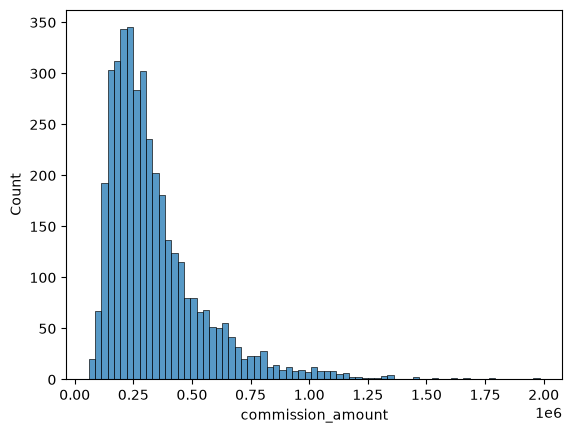

In [8]:
sns.histplot(data = df_transaction['commission_amount'])

<Axes: ylabel='commission_amount'>

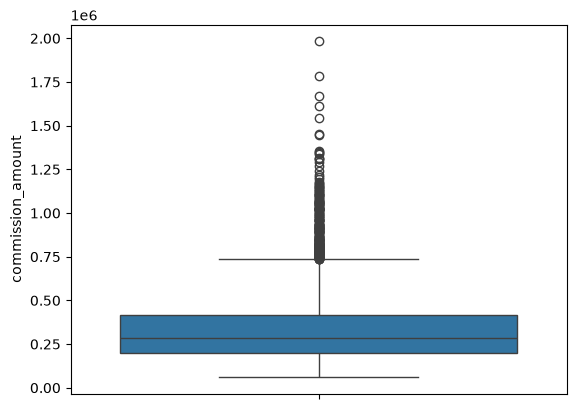

In [9]:
sns.boxplot(data = df_transaction['commission_amount'])

In [10]:
df_transaction['deal_date'] = pd.to_datetime(df_transaction['deal_date'])


In [11]:
monthly_rev = df_transaction[['deal_date','deal_price']]
monthly_rev['deal_year'] = monthly_rev['deal_date'].dt.year
monthly_rev['deal_month'] = monthly_rev['deal_date'].dt.month
monthly_rev['month_num'] = monthly_rev['deal_date'].dt.month
monthly_rev

,deal_date,deal_price,deal_year,deal_month,month_num
0,2024-10-20,20951990.0,2024,10,10
1,2023-09-07,10704517.0,2023,9,9
2,2024-05-30,11306054.0,2024,5,5
3,2023-03-10,7998580.0,2023,3,3
4,2023-07-23,5351976.0,2023,7,7
...,...,...,...,...,...
3917,2022-05-29,9440229.0,2022,5,5
3918,2024-10-05,7530999.0,2024,10,10
3919,2022-12-20,18093012.0,2022,12,12
3920,2023-06-24,9737140.0,2023,6,6


In [12]:
import calendar

monthly_rev['deal_month'] = monthly_rev['deal_month'].apply(lambda x: calendar.month_abbr[x])

In [13]:
monthly_rev

,deal_date,deal_price,deal_year,deal_month,month_num
0,2024-10-20,20951990.0,2024,Oct,10
1,2023-09-07,10704517.0,2023,Sep,9
2,2024-05-30,11306054.0,2024,May,5
3,2023-03-10,7998580.0,2023,Mar,3
4,2023-07-23,5351976.0,2023,Jul,7
...,...,...,...,...,...
3917,2022-05-29,9440229.0,2022,May,5
3918,2024-10-05,7530999.0,2024,Oct,10
3919,2022-12-20,18093012.0,2022,Dec,12
3920,2023-06-24,9737140.0,2023,Jun,6


In [14]:
rev_by_month = monthly_rev.groupby(['deal_year','month_num','deal_month']).agg(total_rev =('deal_price','sum')).reset_index().sort_values(['deal_year','month_num'])
rev_by_month

,deal_year,month_num,deal_month,total_rev
0,2022,1,Jan,1.854321e+08
1,2022,2,Feb,7.406570e+08
2,2022,3,Mar,1.369915e+09
3,2022,4,Apr,1.434284e+09
4,2022,5,May,1.489930e+09
5,2022,6,Jun,1.629911e+09
6,2022,7,Jul,1.550659e+09
7,2022,8,Aug,1.488152e+09
8,2022,9,Sep,1.450269e+09
9,2022,10,Oct,1.462634e+09


In [15]:
rev_by_month = rev_by_month.drop(columns='month_num')

In [16]:
rev_by_month[rev_by_month['deal_year']==2022]

,deal_year,deal_month,total_rev
0,2022,Jan,1.854321e+08
1,2022,Feb,7.406570e+08
2,2022,Mar,1.369915e+09
3,2022,Apr,1.434284e+09
4,2022,May,1.489930e+09
5,2022,Jun,1.629911e+09
6,2022,Jul,1.550659e+09
7,2022,Aug,1.488152e+09
8,2022,Sep,1.450269e+09
9,2022,Oct,1.462634e+09


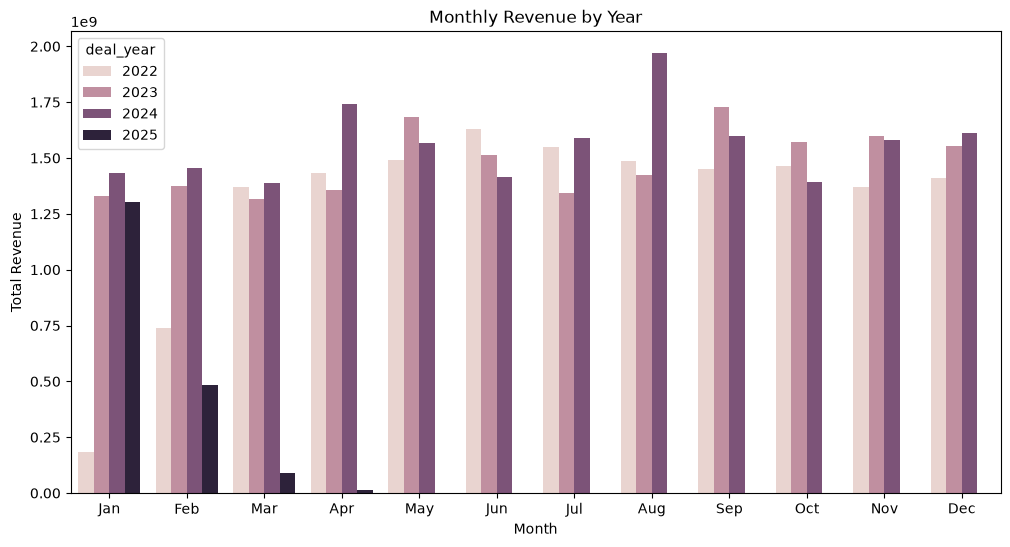

In [17]:

plt.figure(figsize=(12,6))

sns.barplot(
    data=rev_by_month,
    x='deal_month',
    y='total_rev',
    hue='deal_year'
)

plt.title('Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

plt.show()